# Main Data Loading, Prep, Train, Test, Eval Flow

This notebook wires together the existing `traffic_rl` modules for an end-to-end run.

Flow:
1. Load project configs and data paths
2. Inspect PEMS tensor data
3. Build CityFlow demand splits (train/val/test)
4. Train an agent
5. Evaluate trained vs untrained across splits

Each code cell intentionally uses a different output style (text, JSON, HTML table, artifact paths, ASCII bars).

In [1]:
from __future__ import annotations

import copy
import importlib.util
import json
import os
import sys
from dataclasses import asdict
from pathlib import Path

import numpy as np
import yaml
from IPython.display import HTML, JSON, Markdown, display

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate repo root from {start}. Expected pyproject.toml/src/configs in a parent directory."
    )

REPO_ROOT = _find_repo_root(Path.cwd()).resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from traffic_rl.config import load_config
from traffic_rl.evaluation import run_evaluation
from traffic_rl.pems.pipeline import build_cityflow_demands, load_pems_demand_config
from traffic_rl.training import run_training

HAS_CITYFLOW = importlib.util.find_spec("cityflow") is not None
print(f"Working directory: {Path.cwd()}")
print(f"Repository root: {REPO_ROOT}")
print(f"CityFlow available: {HAS_CITYFLOW}")

Working directory: /home/hd/projects/ML_project/traffic-rl/notebooks
Repository root: /home/hd/projects/ML_project/traffic-rl
CityFlow available: True


/home/hd/projects/ML_project/traffic-rl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Set Run Controls

The next code cell defines quick-run settings and paths for configs.
- Keep `QUICK_MODE = True` for fast notebook iteration.
- `EVAL_SEEDS` and `EVAL_EPISODES` control statistical power for significance tests.
- Paths are resolved from the detected repo root, so this works whether you run from the project root or the notebooks folder.

In [2]:
# Quick-mode controls for faster notebook iteration.
QUICK_MODE = False
REWARD_TYPE = "mixed"
if QUICK_MODE:
    TRAIN_EPISODES = 3
    TRAIN_MAX_STEPS = 40
    EVAL_EPISODES = 8
    EVAL_SEEDS = 3
    SIGNIFICANCE_BOOTSTRAP_SAMPLES = 1000
    SIGNIFICANCE_PERMUTATION_SAMPLES = 3000
else:
    TRAIN_EPISODES = 45
    TRAIN_MAX_STEPS = 150
    EVAL_EPISODES = 12
    EVAL_SEEDS = 7
    SIGNIFICANCE_BOOTSTRAP_SAMPLES = 5000
    SIGNIFICANCE_PERMUTATION_SAMPLES = 20000

# Shared agent hyperparameters matched to the benchmark notebook and CLI.
SHARED_HYPERPARAMS = {
    "gamma": 0.99,
    "learning_rate": 0.0002,  # More conservative updates for mixed reward stability
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 0.999,  # Slower decay for broader state-action coverage
    "hidden_dim": 64,
    "batch_size": 32,
    "replay_capacity": 10000,
    "learning_starts": 200,
    "target_update_interval": 150,
    "train_frequency": 4,
    "seed": 42,
}

def apply_shared_hyperparams(cfg):
    cfg.reward.type = REWARD_TYPE
    cfg.training.agent_type = "dqn"
    cfg.training.gamma = SHARED_HYPERPARAMS["gamma"]
    cfg.training.learning_rate = SHARED_HYPERPARAMS["learning_rate"]
    cfg.training.epsilon_start = SHARED_HYPERPARAMS["epsilon_start"]
    cfg.training.epsilon_end = SHARED_HYPERPARAMS["epsilon_end"]
    cfg.training.epsilon_decay = SHARED_HYPERPARAMS["epsilon_decay"]
    cfg.training.hidden_dim = SHARED_HYPERPARAMS["hidden_dim"]
    cfg.training.batch_size = SHARED_HYPERPARAMS["batch_size"]
    cfg.training.replay_capacity = SHARED_HYPERPARAMS["replay_capacity"]
    cfg.training.learning_starts = SHARED_HYPERPARAMS["learning_starts"]
    cfg.training.target_update_interval = SHARED_HYPERPARAMS["target_update_interval"]
    cfg.training.train_frequency = SHARED_HYPERPARAMS["train_frequency"]
    cfg.training.freeze_on_epsilon_end = False  # Keep learning even after epsilon min
    return cfg

PEMS_CONFIG_PATH = REPO_ROOT / "configs" / "pems04_to_cityflow.example.yaml"
CITYFLOW_BASE_CONFIG_PATH = REPO_ROOT / "configs" / "cityflow.quick.yaml"
MOCK_BASE_CONFIG_PATH = REPO_ROOT / "configs" / "default.yaml"

path_status = {
    "quick_mode": QUICK_MODE,
    "reward_type": REWARD_TYPE,
    "train_episodes": TRAIN_EPISODES,
    "train_max_steps": TRAIN_MAX_STEPS,
    "eval_episodes": EVAL_EPISODES,
    "eval_seeds": EVAL_SEEDS,
    "significance": {
        "bootstrap_samples": SIGNIFICANCE_BOOTSTRAP_SAMPLES,
        "permutation_samples": SIGNIFICANCE_PERMUTATION_SAMPLES,
    },
    "paths": {
        "pems_config": {"path": str(PEMS_CONFIG_PATH), "exists": PEMS_CONFIG_PATH.exists()},
        "cityflow_base_config": {"path": str(CITYFLOW_BASE_CONFIG_PATH), "exists": CITYFLOW_BASE_CONFIG_PATH.exists()},
        "mock_base_config": {"path": str(MOCK_BASE_CONFIG_PATH), "exists": MOCK_BASE_CONFIG_PATH.exists()},
    },
}
display(JSON(path_status, expanded=True))

<IPython.core.display.JSON object>

## Step 2: Inspect Raw PEMS Tensor

The next cell loads the PEMS NPZ file and prints distribution stats.
This is a sanity check before generating any CityFlow demand files.
If shape or value ranges look unexpected, stop here and verify the source data/config first.

In [3]:
pems_cfg = load_pems_demand_config(PEMS_CONFIG_PATH)
pems_npz = np.load(pems_cfg.pems_npz_path)
tensor = pems_npz["data"]

stats = {
    "shape": tuple(int(v) for v in tensor.shape),
    "dtype": str(tensor.dtype),
    "min": float(tensor.min()),
    "mean": float(tensor.mean()),
    "max": float(tensor.max()),
}

flow_feature_idx = pems_cfg.flow_feature_index
sensor_rows = []
for sensor_idx in pems_cfg.sensor_indices[:4]:
    values = tensor[:, sensor_idx, flow_feature_idx]
    sensor_rows.append(
        f"<tr><td>{sensor_idx}</td><td>{float(values.min()):.2f}</td><td>{float(values.mean()):.2f}</td><td>{float(values.max()):.2f}</td></tr>"
    )

table_html = ""
table_html += "<h3>PEMS Data Snapshot (HTML Table Output)</h3>"
table_html += "<p>Tensor shape: {} | dtype: {}</p>".format(stats["shape"], stats["dtype"])
table_html += "<table border='1' cellpadding='6'><tr><th>Sensor</th><th>Min</th><th>Mean</th><th>Max</th></tr>"
table_html += "".join(sensor_rows)
table_html += "</table>"

display(HTML(table_html))
print("Global stats:", stats)

Sensor,Min,Mean,Max
0,0.00,244.29,626.00
1,0.00,196.51,536.00
2,0.00,239.96,660.00
3,0.00,187.08,507.00


Global stats: {'shape': (16992, 307, 3), 'dtype': 'float64', 'min': 0.0, 'mean': 91.74140778613855, 'max': 919.0}


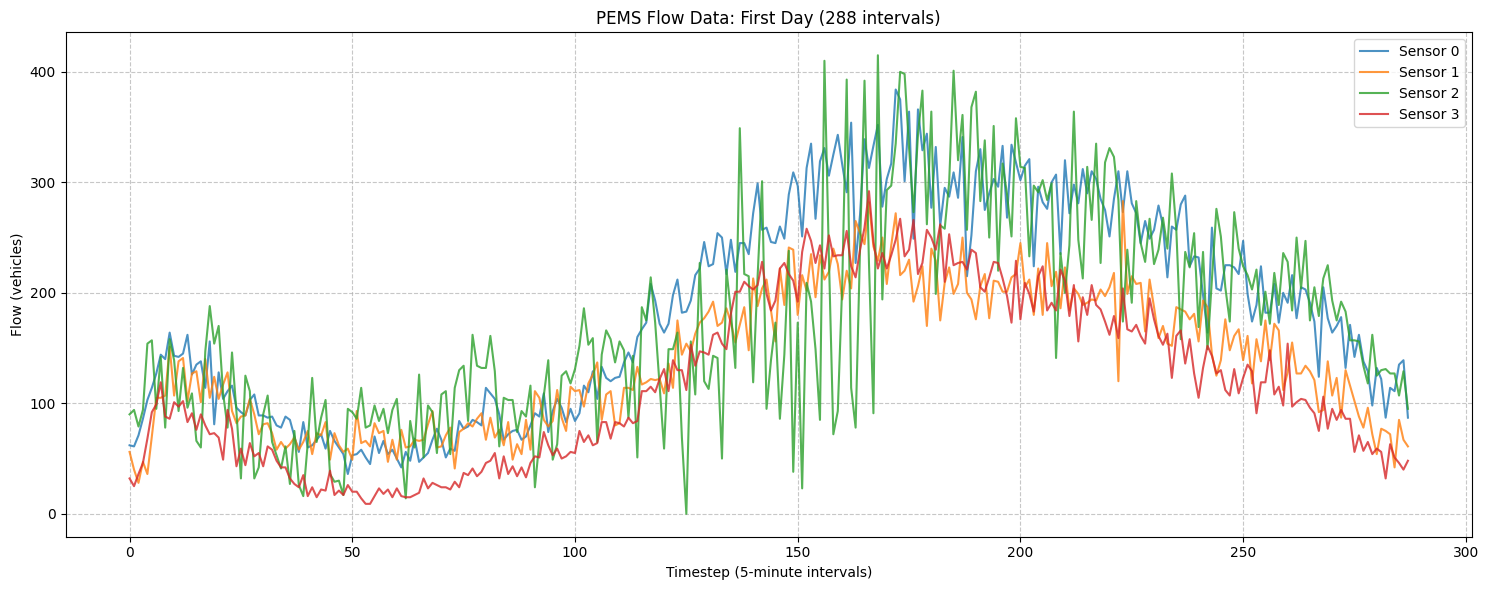

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the flow_feature_idx and sensor_indices from pems_cfg that we loaded earlier
# Plotting the flow data for the first 4 sensors over the first 288 timesteps (one full day if 5 min intervals)
num_sensors_to_plot = min(4, len(pems_cfg.sensor_indices))
timesteps_to_plot = min(288, tensor.shape[0])

plt.figure(figsize=(15, 6))
for i in range(num_sensors_to_plot):
    sensor_idx = pems_cfg.sensor_indices[i]
    # Get the flow values for this sensor
    flow_data = tensor[:timesteps_to_plot, sensor_idx, flow_feature_idx]
    plt.plot(flow_data, label=f'Sensor {sensor_idx}', alpha=0.8)

plt.title('PEMS Flow Data: First Day (288 intervals)')
plt.xlabel('Timestep (5-minute intervals)')
plt.ylabel('Flow (vehicles)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Step 3: Build CityFlow Demand Splits

This step runs your existing demand pipeline to create train/val/test flow files.
Quick mode reduces sensors and split sizes so the notebook stays responsive.
The output summary shows generated vehicle counts and split metadata.

In [5]:
prep_cfg = copy.deepcopy(pems_cfg)

if QUICK_MODE:
    if len(prep_cfg.sensor_indices) > 2:
        prep_cfg.sensor_indices = prep_cfg.sensor_indices[:2]
    prep_cfg.split.train_days = 1
    prep_cfg.split.val_days = 1
    prep_cfg.split.test_days = 1
    prep_cfg.arrival_process = "uniform"

prep_output_dir = REPO_ROOT / "outputs" / ("pems04_notebook_quick" if QUICK_MODE else "pems04_notebook_full")
prep_cfg.output_dir = str(prep_output_dir)

prep_outputs = build_cityflow_demands(prep_cfg)
prep_summary = json.loads(Path(prep_outputs.summary_file).read_text(encoding="utf-8"))

display(Markdown("### Demand Build Artifacts"))
print(f"train flow : {prep_outputs.train_flow_file}")
print(f"val flow   : {prep_outputs.val_flow_file}")
print(f"test flow  : {prep_outputs.test_flow_file}")
print(f"summary    : {prep_outputs.summary_file}")
display(JSON(prep_summary, expanded=True))

Building test split: 100%|██████████| 288/288 [00:00<00:00, 470.61window/s]


### Demand Build Artifacts

train flow : /home/hd/projects/ML_project/traffic-rl/outputs/pems04_notebook_full/flow_train.json
val flow   : /home/hd/projects/ML_project/traffic-rl/outputs/pems04_notebook_full/flow_val.json
test flow  : /home/hd/projects/ML_project/traffic-rl/outputs/pems04_notebook_full/flow_test.json
summary    : /home/hd/projects/ML_project/traffic-rl/outputs/pems04_notebook_full/summary.json


<IPython.core.display.JSON object>

## Step 3.5: Postprocessed CityFlow Demand Preview

The next cell shows what the generated CityFlow demand files look like.
It summarizes each split and displays sample vehicle entries so you can inspect the final postprocessed format.

In [6]:
split_flow_files = {
    "train": Path(prep_outputs.train_flow_file),
    "val": Path(prep_outputs.val_flow_file),
    "test": Path(prep_outputs.test_flow_file),
}

def _compact_entry(entry: dict) -> dict:
    return {
        "startTime": int(entry.get("startTime", 0)),
        "endTime": int(entry.get("endTime", 0)),
        "route": entry.get("route", []),
        "interval": float(entry.get("interval", 1.0)),
    }

def _summarize_postprocessed_flow(path: Path, preview_n: int = 2) -> dict:
    entries = json.loads(path.read_text(encoding="utf-8"))
    count = len(entries)

    if count == 0:
        return {
            "path": str(path),
            "vehicle_count": 0,
            "start_time_min": None,
            "start_time_max": None,
            "unique_route_count_from_first_5k": 0,
            "sample_entries_compact": [],
        }

    start_times = [int(item.get("startTime", 0)) for item in entries]
    route_strings = [" -> ".join(item.get("route", [])) for item in entries[: min(5000, count)]]
    unique_route_count = len(set(route_strings))

    return {
        "path": str(path),
        "vehicle_count": int(count),
        "start_time_min": int(min(start_times)),
        "start_time_max": int(max(start_times)),
        "unique_route_count_from_first_5k": int(unique_route_count),
        "sample_entries_compact": [_compact_entry(entry) for entry in entries[:preview_n]],
    }

postprocessed_preview = {
    split_name: _summarize_postprocessed_flow(flow_path)
    for split_name, flow_path in split_flow_files.items()
}

table_html = ""
table_html += "<h4>Postprocessed Split Summary</h4>"
table_html += "<table border='1' cellpadding='6'>"
table_html += "<tr><th>Split</th><th>Vehicle Count</th><th>Start Time Min</th><th>Start Time Max</th><th>Unique Routes (first 5k)</th></tr>"
for split_name in ("train", "val", "test"):
    row = postprocessed_preview[split_name]
    table_html += (
        f"<tr><td>{split_name}</td><td>{row['vehicle_count']}</td><td>{row['start_time_min']}</td>"
        f"<td>{row['start_time_max']}</td><td>{row['unique_route_count_from_first_5k']}</td></tr>"
    )
table_html += "</table>"
display(HTML(table_html))

print("Compact sample entries by split:")
for split_name in ("train", "val", "test"):
    print(f"\n{split_name} sample:")
    print(json.dumps(postprocessed_preview[split_name]["sample_entries_compact"], indent=2))

Split,Vehicle Count,Start Time Min,Start Time Max,Unique Routes (first 5k)
train,437726,0,172795,8
val,263435,0,86398,8
test,267204,0,86399,8


Compact sample entries by split:

train sample:
[
  {
    "startTime": 0,
    "endTime": 0,
    "route": [
      "road_2_0_1",
      "road_2_1_1",
      "road_2_2_1"
    ],
    "interval": 1.0
  },
  {
    "startTime": 2,
    "endTime": 2,
    "route": [
      "road_1_0_1",
      "road_1_1_1",
      "road_1_2_1"
    ],
    "interval": 1.0
  }
]

val sample:
[
  {
    "startTime": 0,
    "endTime": 0,
    "route": [
      "road_1_0_1",
      "road_1_1_1",
      "road_1_2_1"
    ],
    "interval": 1.0
  },
  {
    "startTime": 1,
    "endTime": 1,
    "route": [
      "road_0_1_0",
      "road_1_1_0",
      "road_2_1_0"
    ],
    "interval": 1.0
  }
]

test sample:
[
  {
    "startTime": 0,
    "endTime": 0,
    "route": [
      "road_0_2_0",
      "road_1_2_0",
      "road_2_2_0"
    ],
    "interval": 1.0
  },
  {
    "startTime": 1,
    "endTime": 1,
    "route": [
      "road_3_1_2",
      "road_2_1_2",
      "road_1_1_2"
    ],
    "interval": 1.0
  }
]


## Step 4: Input to Output Transformation View

This cell focuses on the transformation itself:
- input: per-window flow values from the PEMS tensor
- output: per-vehicle CityFlow records

> `startTime` and `endTime` are departure timestamps in simulation seconds.
In this generated format they are equal, so we treat them as one `departure_second` for readability.

In [7]:
train_flow_entries = json.loads(Path(prep_outputs.train_flow_file).read_text(encoding="utf-8"))
val_flow_entries = json.loads(Path(prep_outputs.val_flow_file).read_text(encoding="utf-8"))
test_flow_entries = json.loads(Path(prep_outputs.test_flow_file).read_text(encoding="utf-8"))

summary_rows = [
    ("train", len(train_flow_entries)),
    ("val", len(val_flow_entries)),
    ("test", len(test_flow_entries)),
]

table_html = ""
table_html += "<h4>Generated Vehicle Records by Split</h4>"
table_html += "<table border='1' cellpadding='6'>"
table_html += "<tr><th>Split</th><th>Vehicle Records</th></tr>"
for split_name, count in summary_rows:
    table_html += f"<tr><td>{split_name}</td><td>{count}</td></tr>"
table_html += "</table>"
display(HTML(table_html))

sensor_idx = int(prep_cfg.sensor_indices[0])
timestep_idx = 0
raw_flow_value = float(tensor[timestep_idx, sensor_idx, prep_cfg.flow_feature_index])

if prep_cfg.arrival_process == "uniform":
    rule_text = "round(flow_value)"
    expected_count = int(round(max(0.0, raw_flow_value)))
else:
    rule_text = "poisson(flow_value)"
    expected_count = float(max(0.0, raw_flow_value))

window_size = int(prep_cfg.sampling_interval_sec)
window_start = 0
window_end = window_size
window0_entries = [
    item
    for item in train_flow_entries
    if window_start <= int(item.get("startTime", 0)) < window_end
]

demo_output_rows = [
    {
        "departure_second": int(item.get("startTime", 0)),
        "route": " -> ".join(item.get("route", [])),
    }
    for item in window0_entries[:5]
]

transformation_demo = {
    "input_example": {
        "timestep_index": int(timestep_idx),
        "sensor_index": int(sensor_idx),
        "flow_value": float(raw_flow_value),
        "arrival_process": str(prep_cfg.arrival_process),
        "sampling_rule": rule_text,
        "expected_generated_vehicles_from_input": expected_count,
    },
    "output_example": {
        "window_seconds": [int(window_start), int(window_end)],
        "actual_generated_records_in_window": int(len(window0_entries)),
        "sample_vehicle_records": demo_output_rows,
    },
}

display(JSON(transformation_demo, expanded=True))

Split,Vehicle Records
train,437726
val,263435
test,267204


<IPython.core.display.JSON object>

In [8]:
def _resolve_from_yaml(config_path: Path, value: str) -> str:
    path = Path(value)
    if path.is_absolute():
        return str(path)
    return str((config_path.parent / path).resolve())


def _resolve_engine_dir(base_engine_path: Path, engine_dir_value: str, repo_root: Path) -> Path:
    engine_dir_path = Path(engine_dir_value)
    if not engine_dir_path.is_absolute():
        engine_dir_path = (base_engine_path.parent / engine_dir_path).resolve()

    # Some shared example configs contain machine-specific absolute paths.
    # If the configured dir is missing, fall back to this repo's CityFlow data directory.
    if not engine_dir_path.exists():
        fallback = (repo_root / "cityflow_data").resolve()
        if fallback.exists():
            return fallback
    return engine_dir_path.resolve()


def _to_engine_relative(engine_dir: Path, flow_path: Path) -> str:
    return os.path.relpath(flow_path.resolve(), engine_dir.resolve())


def _to_cityflow_dir_string(engine_dir: Path) -> str:
    value = str(engine_dir.resolve())
    # CityFlow expects a directory prefix string; keep trailing separator explicit.
    if not value.endswith(os.sep):
        value += os.sep
    return value


split_cfg_paths: dict[str, str] = {}
split_mode = "mock"

if HAS_CITYFLOW and CITYFLOW_BASE_CONFIG_PATH.exists():
    split_mode = "cityflow"
    base_raw = yaml.safe_load(CITYFLOW_BASE_CONFIG_PATH.read_text(encoding="utf-8")) or {}
    base_engine_path = Path(_resolve_from_yaml(CITYFLOW_BASE_CONFIG_PATH, str(base_raw["env"]["cityflow_config_path"])))
    engine_raw = json.loads(base_engine_path.read_text(encoding="utf-8"))

    notebook_cfg_dir = REPO_ROOT / "outputs" / "notebook_run"
    notebook_cfg_dir.mkdir(parents=True, exist_ok=True)

    split_to_flow = {
        "train": Path(prep_outputs.train_flow_file),
        "val": Path(prep_outputs.val_flow_file),
        "test": Path(prep_outputs.test_flow_file),
    }

    for split_name, flow_path in split_to_flow.items():
        split_engine = copy.deepcopy(engine_raw)
        resolved_engine_dir = _resolve_engine_dir(base_engine_path, str(split_engine.get("dir", ".")), REPO_ROOT)
        split_engine["dir"] = _to_cityflow_dir_string(resolved_engine_dir)
        split_engine["flowFile"] = _to_engine_relative(resolved_engine_dir, flow_path)

        engine_out = notebook_cfg_dir / f"cityflow_engine_{split_name}.json"
        engine_out.write_text(json.dumps(split_engine, indent=2), encoding="utf-8")

        split_cfg_raw = copy.deepcopy(base_raw)
        split_cfg_raw["env"]["cityflow_config_path"] = str(engine_out)
        split_cfg_path = notebook_cfg_dir / f"cityflow_{split_name}.yaml"
        split_cfg_path.write_text(yaml.safe_dump(split_cfg_raw, sort_keys=False), encoding="utf-8")
        split_cfg_paths[split_name] = str(split_cfg_path)
else:
    split_cfg_paths = {
        "train": str(MOCK_BASE_CONFIG_PATH),
        "val": str(MOCK_BASE_CONFIG_PATH),
        "test": str(MOCK_BASE_CONFIG_PATH),
    }

display(JSON({
    "split_mode": split_mode,
    "split_config_paths": split_cfg_paths,
}, expanded=True))

<IPython.core.display.JSON object>

## Step 5: Create Split-Specific Runtime Configs

This cell prepares per-split config files used for training and evaluation.
If CityFlow is available, it rewrites the engine `flowFile` for each split.
If not, it falls back to mock backend configs so the notebook still runs end-to-end.

In [9]:
train_cfg = load_config(split_cfg_paths["train"])
apply_shared_hyperparams(train_cfg)
train_cfg.seed = SHARED_HYPERPARAMS["seed"]
train_cfg.training.episodes = TRAIN_EPISODES
train_cfg.training.max_steps = TRAIN_MAX_STEPS
train_cfg.output_dir = str(REPO_ROOT / "outputs" / "notebook_run")

train_summary = run_training(train_cfg)

def _bar(value: float, scale: float = 3.0, width: int = 30) -> str:
    clipped = max(-width, min(width, int(round(value / scale))))
    if clipped >= 0:
        return "+" * clipped
    return "-" * abs(clipped)

episode_rewards = np.asarray(train_summary.episode_rewards, dtype=np.float64)
rolling_window = min(5, len(episode_rewards))
rolling_mean = np.array([
    float(np.mean(episode_rewards[max(0, idx - rolling_window + 1): idx + 1]))
    for idx in range(len(episode_rewards))
], dtype=np.float64)

print(f"Training episodes: {train_summary.episodes}")
print(f"Average reward : {train_summary.average_reward:.3f}")
print(f"Rolling mean   : window={rolling_window}")
print("Episode rewards (ASCII bars):")
for idx, reward in enumerate(train_summary.episode_rewards, start=1):
    print(f"  ep {idx:02d} | {reward:8.3f} | {_bar(reward)} | roll={rolling_mean[idx - 1]:8.3f}")
print()
print("Note: CityFlow resets with a different seed each episode, so raw episode rewards are noisy and not directly monotonic.")

Training episodes:   2%|▏         | 1/45 [00:04<03:15,  4.45s/ep, avg=-2015.9, reward=-2015.9, trend=[#############---]]

[train] ep 001/045 reward= -2015.9 avg= -2015.9 [#############---]


Training episodes:   4%|▍         | 2/45 [00:08<03:09,  4.42s/ep, avg=-1705.0, reward=-1394.2, trend=[##############--]]

[train] ep 002/045 reward= -1394.2 avg= -1705.0 [##############--]


Training episodes:   7%|▋         | 3/45 [00:13<03:06,  4.43s/ep, avg=-1612.4, reward=-1427.2, trend=[##############--]]

...

[train] ep 043/045 reward=  -211.0 avg=  -606.0 [################]


Training episodes:  98%|█████████▊| 44/45 [03:15<00:04,  4.51s/ep, avg=-596.4, reward=-185.3, trend=[################]]

[train] ep 044/045 reward=  -185.3 avg=  -596.4 [################]


Training episodes: 100%|██████████| 45/45 [03:19<00:00,  4.44s/ep, avg=-587.3, reward=-188.2, trend=[################]]

[train] ep 045/045 reward=  -188.2 avg=  -587.3 [################]
Training episodes: 45
Average reward : -587.331
Rolling mean   : window=5
Episode rewards (ASCII bars):
  ep 01 | -2015.932 | ------------------------------ | roll=-2015.932
  ep 02 | -1394.168 | ------------------------------ | roll=-1705.050
  ep 03 | -1427.207 | ------------------------------ | roll=-1612.436
  ep 04 | -692.078 | ------------------------------ | roll=-1382.346
  ep 05 | -950.697 | ------------------------------ | roll=-1296.016
  ep 06 | -781.130 | ------------------------------ | roll=-1049.056
  ep 07 | -802.421 | ------------------------------ | roll=-930.707
  ep 08 | -790.973 | ------------------------------ | roll=-803.460
  ep 09 | -803.215 | ------------------------------ | roll=-825.687
  ep 10 | -762.532 | ------------------------------ | roll=-788.054
  ep 11 | -733.398 | ------------------------------ | roll=-778.508
  ep 12 | -385.183 | ------------------------------ | roll=-695.060
  ep

## Step 6: Train Agent on Train Split

Training uses your current `TRAIN_EPISODES` and `TRAIN_MAX_STEPS` settings.
The ASCII bars provide a quick visual of per-episode reward behavior.
A backend-specific checkpoint is saved under `outputs/notebook_run`.

In [10]:
from traffic_rl.analysis import compare_reward_distributions

eval_rows = []

for split_name in ("train", "val", "test"):
    base_eval_cfg = load_config(split_cfg_paths[split_name])
    apply_shared_hyperparams(base_eval_cfg)
    base_eval_cfg.seed = SHARED_HYPERPARAMS["seed"]
    base_eval_cfg.training.max_steps = TRAIN_MAX_STEPS
    base_eval_cfg.output_dir = train_cfg.output_dir

    trained_rewards_all: list[float] = []
    untrained_rewards_all: list[float] = []
    trained_queue_means: list[float] = []
    untrained_queue_means: list[float] = []

    for seed_offset in range(EVAL_SEEDS):
        run_seed = int(base_eval_cfg.seed + seed_offset)

        trained_cfg = copy.deepcopy(base_eval_cfg)
        trained_cfg.seed = run_seed
        trained = run_evaluation(
            trained_cfg,
            episodes=EVAL_EPISODES,
            checkpoint_path=None,
            replay_file=None,
            load_checkpoint=True,
            show_progress=False,
        )

        untrained_cfg = copy.deepcopy(base_eval_cfg)
        untrained_cfg.seed = run_seed
        untrained = run_evaluation(
            untrained_cfg,
            episodes=EVAL_EPISODES,
            checkpoint_path=None,
            replay_file=None,
            load_checkpoint=False,
            show_progress=False,
        )

        trained_rewards_all.extend(float(v) for v in trained.episode_rewards)
        untrained_rewards_all.extend(float(v) for v in untrained.episode_rewards)
        trained_queue_means.append(float(trained.average_queue))
        untrained_queue_means.append(float(untrained.average_queue))

    stats = compare_reward_distributions(
        np.asarray(trained_rewards_all, dtype=np.float64),
        np.asarray(untrained_rewards_all, dtype=np.float64),
        seed=int(base_eval_cfg.seed),
        bootstrap_samples=SIGNIFICANCE_BOOTSTRAP_SAMPLES,
        permutation_samples=SIGNIFICANCE_PERMUTATION_SAMPLES,
    )

    eval_rows.append({
        "split": split_name,
        "num_seeds": int(EVAL_SEEDS),
        "episodes_per_seed": int(EVAL_EPISODES),
        "num_samples_per_policy": int(len(trained_rewards_all)),
        "trained_avg_reward": float(stats.trained_mean),
        "untrained_avg_reward": float(stats.untrained_mean),
        "delta": float(stats.mean_diff),
        "trained_avg_queue": float(np.mean(trained_queue_means) if trained_queue_means else 0.0),
        "untrained_avg_queue": float(np.mean(untrained_queue_means) if untrained_queue_means else 0.0),
        "p_value": float(stats.p_value),
        "ci95_low": float(stats.ci_low),
        "ci95_high": float(stats.ci_high),
        "cohen_d": float(stats.cohen_d),
        "is_significant_0_05": bool(stats.p_value < 0.05),
    })

html = ""
html += "<h3>Evaluation Summary (HTML Table)</h3>"
html += "<table border='1' cellpadding='6'>"
html += (
    "<tr><th>Split</th><th>Seeds</th><th>Episodes/Seed</th><th>N (per policy)</th>"
    "<th>Trained Avg Reward</th><th>Untrained Avg Reward</th><th>Delta</th>"
    "<th>Trained Avg Queue</th><th>Untrained Avg Queue</th><th>p-value</th><th>95% CI (Delta)</th>"
    "<th>Cohen's d</th><th>Significant @ 0.05</th></tr>"
)
for row in eval_rows:
    html += (
        f"<tr><td>{row['split']}</td><td>{row['num_seeds']}</td><td>{row['episodes_per_seed']}</td>"
        f"<td>{row['num_samples_per_policy']}</td><td>{row['trained_avg_reward']:.3f}</td>"
        f"<td>{row['untrained_avg_reward']:.3f}</td><td>{row['delta']:.3f}</td>"
        f"<td>{row['trained_avg_queue']:.3f}</td><td>{row['untrained_avg_queue']:.3f}</td><td>{row['p_value']:.5f}</td>"
        f"<td>[{row['ci95_low']:.3f}, {row['ci95_high']:.3f}]</td><td>{row['cohen_d']:.3f}</td>"
        f"<td>{'Yes' if row['is_significant_0_05'] else 'No'}</td></tr>"
    )
html += "</table>"
display(HTML(html))
eval_rows

Split,Seeds,Episodes/Seed,N (per policy),Trained Avg Reward,Untrained Avg Reward,Delta,Trained Avg Queue,Untrained Avg Queue,p-value,95% CI (Delta),Cohen's d,Significant @ 0.05
train,7,12,84,-186.080,-2527.800,2341.719,0.135,3.659,0.00005,"[2299.677, 2379.517]",17.760,Yes
val,7,12,84,-877.948,-2649.018,1771.070,1.026,3.860,0.00005,"[1764.731, 1777.314]",85.376,Yes
test,7,12,84,-195.381,-2610.279,2414.897,0.158,3.814,0.00005,"[2365.194, 2459.628]",15.184,Yes


[{'split': 'train',
  'num_seeds': 7,
  'episodes_per_seed': 12,
  'num_samples_per_policy': 84,
  'trained_avg_reward': -186.08038710760292,
  'untrained_avg_reward': -2527.7996659401715,
  'delta': 2341.7192788325688,
  'trained_avg_queue': 0.13489583333333333,
  'untrained_avg_queue': 3.6594494047619044,
  'p_value': 4.999750012499375e-05,
  'ci95_low': 2299.6770818800765,
  'ci95_high': 2379.5166300267388,
  'cohen_d': 17.760161142114338,
  'is_significant_0_05': True},
 {'split': 'val',
  'num_seeds': 7,
  'episodes_per_seed': 12,
  'num_samples_per_policy': 84,
  'trained_avg_reward': -877.948165301651,
  'untrained_avg_reward': -2649.018199136471,
  'delta': 1771.0700338348202,
  'trained_avg_queue': 1.0255208333333334,
  'untrained_avg_queue': 3.8597470238095233,
  'p_value': 4.999750012499375e-05,
  'ci95_low': 1764.7305303926164,
  'ci95_high': 1777.3139108519501,
  'cohen_d': 85.37594987757058,
  'is_significant_0_05': True},
 {'split': 'test',
  'num_seeds': 7,
  'episodes_

## Step 7: Evaluate Trained vs Untrained and Save Report

The evaluation cell compares trained and untrained policies on train/val/test splits.
It aggregates metrics across multiple seeds and episodes for stronger statistical power.
Focus on `delta`, queue metrics, and significance-test outputs (`p_value`, `95% CI`, `cohen_d`, significance flag).
The final cell persists a compact JSON report for downstream analysis or plotting.

In [11]:
report = {
    "meta": {
        "quick_mode": QUICK_MODE,
        "split_mode": split_mode,
        "train_episodes": TRAIN_EPISODES,
        "eval_episodes": EVAL_EPISODES,
        "eval_seeds": EVAL_SEEDS,
        "train_max_steps": TRAIN_MAX_STEPS,
        "significance_bootstrap_samples": SIGNIFICANCE_BOOTSTRAP_SAMPLES,
        "significance_permutation_samples": SIGNIFICANCE_PERMUTATION_SAMPLES,
    },
    "prep_summary": prep_summary,
    "training": asdict(train_summary),
    "evaluation": eval_rows,
}

report_path = Path(train_cfg.output_dir) / "notebook_flow_report.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

display(Markdown(f"### Saved notebook report\n`{report_path}`"))
print(json.dumps(report["meta"], indent=2))

### Saved notebook report
`/home/hd/projects/ML_project/traffic-rl/outputs/notebook_run/notebook_flow_report.json`

{
  "quick_mode": false,
  "split_mode": "cityflow",
  "train_episodes": 45,
  "eval_episodes": 12,
  "eval_seeds": 7,
  "train_max_steps": 150,
  "significance_bootstrap_samples": 5000,
  "significance_permutation_samples": 20000
}
